# Duplicate Records — the error that silently inflates every number you report

01 Core Python · 02 Pandas · **▶ 03 Cleaning** · 04 Transformation · 05 Feature Engineering · 06 Regression · 07 Model Prep · 08 Case Studies · 09 Deployment

`03_Data_Cleaning/04_duplicate_records.ipynb`

---

### In one paragraph (no jargon)

A duplicated row doesn't look like an error. Nothing crashes, no warning appears — you just quietly count one customer twice, and every total, average and correlation you report is wrong by an amount nobody can see. Duplicates arrive from re-submitted forms, repeated imports and joins that matched too many rows. This notebook covers finding them under three different definitions of "the same record", and the judgement call about which rows to keep.

### After this notebook you can

- Find exact duplicate rows and remove them, choosing which copy survives
- Find partial duplicates on a chosen subset of columns, and understand the false-positive risk
- Catch near-duplicates caused by case, whitespace and typos
- Decide when two similar rows are genuinely two different records


### What's inside

1. Setup and first look
2. Full-row duplicate detection
3. Subset-based (partial) duplicates
4. Fuzzy / near-duplicate detection
5. Visual summary
6. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_test1():
    """Exact copy of test1.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """name,income,age,city,gender
krishna,30000,25,bangalore,M
Raju,50000,28,delhi,M
ramya,25000,35,bangalore,F
krishna,30000,25,bangalore,M
rangaraj,40000,45,pune,M
ramani,15000,20,bangalore,F
krishna,30000,25,bangalore,M
rama,20000,20,delhi,F
Raju,50000,28,delhi,M
shiva,40000,35,pune,M
ramani,15000,20,bangalore,F
krishna,30000,25,bangalore,M
hari,12000,25,pune,M
Raju,50000,28,delhi,M
nitya,60000,47,delhi,F
krishna,30000,35,pune,M"""
    return pd.read_csv(io.StringIO(csv_text))

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


# Detecting & Handling Duplicate Records

**Dataset:** `test1.csv` — 16 rows of customer records (name, income, age, city, gender), with several real, intentional duplicates already baked in.

Duplicate records are one of the most common — and most underestimated — data quality problems. They silently inflate counts, bias averages toward whoever got duplicated, and can leak identical rows across a train/test split. This notebook covers detection and treatment end-to-end, plus a fuzzy-matching technique for duplicates that *aren't* byte-for-byte identical (a synthetic extension, clearly marked below, since the original data doesn't contain any typo-style near-duplicates).

## 1. Load & first look

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="crest")
plt.rcParams['figure.dpi'] = 100

df = load_data('test1.csv', rebuild=rebuild_test1)
print(f"Shape: {df.shape}")
df

Loaded 'test1.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape: (16, 5)


,name,income,age,city,gender
0,krishna,30000,25,bangalore,M
1,Raju,50000,28,delhi,M
2,ramya,25000,35,bangalore,F
3,krishna,30000,25,bangalore,M
4,rangaraj,40000,45,pune,M
5,ramani,15000,20,bangalore,F
6,krishna,30000,25,bangalore,M
7,rama,20000,20,delhi,F
8,Raju,50000,28,delhi,M
9,shiva,40000,35,pune,M


## 2. Full-row duplicate detection
A **full duplicate** matches on *every* column. `df.duplicated()` flags each repeat occurrence (keeping the first as "original" by default).

In [3]:
# 🔧 CHANGE THIS: keep='first' (default) flags the repeats only; keep='last' flags all but
# the last; keep=False flags EVERY copy including the original — use that one for inspection.
full_dupes_mask = df.duplicated(keep=False)  # keep=False marks ALL copies, not just the extras
print(f"Rows involved in a full duplicate group: {full_dupes_mask.sum()} out of {len(df)}")
df[full_dupes_mask].sort_values(list(df.columns))

Rows involved in a full duplicate group: 9 out of 16


,name,income,age,city,gender
1,Raju,50000,28,delhi,M
8,Raju,50000,28,delhi,M
13,Raju,50000,28,delhi,M
0,krishna,30000,25,bangalore,M
3,krishna,30000,25,bangalore,M
6,krishna,30000,25,bangalore,M
11,krishna,30000,25,bangalore,M
5,ramani,15000,20,bangalore,F
10,ramani,15000,20,bangalore,F


In [4]:
# `keep` parameter controls which copy survives a de-dup pass:
#   keep='first' (default) -> keep the first occurrence, drop the rest
#   keep='last'            -> keep the last occurrence, drop the rest
#   keep=False             -> drop ALL copies (including the "original")
dedup_first = df.drop_duplicates(keep='first')
dedup_last = df.drop_duplicates(keep='last')
dedup_none = df.drop_duplicates(keep=False)

print(f"Original rows:                {len(df)}")
print(f"After drop_duplicates(first):  {len(dedup_first)}  (kept the FIRST of each dup group)")
print(f"After drop_duplicates(last):   {len(dedup_last)}  (kept the LAST of each dup group)")
print(f"After drop_duplicates(False):  {len(dedup_none)}  (dropped dup groups ENTIRELY -- use with care!)")

Original rows:                16
After drop_duplicates(first):  10  (kept the FIRST of each dup group)
After drop_duplicates(last):   10  (kept the LAST of each dup group)
After drop_duplicates(False):  7  (dropped dup groups ENTIRELY -- use with care!)


## 3. Subset-based ("partial") duplicate detection
Sometimes two rows aren't fully identical but agree on the columns that matter for your definition of "the same entity" — e.g., same name + same income. This is powerful, but **riskier**: it can produce false positives if two genuinely different people happen to share those columns.

In [5]:
# Duplicate-by-name: are there two "krishna" rows that AREN'T full duplicates?
name_dupes = df[df.duplicated(subset=['name'], keep=False)]
print("All rows sharing a name with at least one other row:")
name_dupes.sort_values('name')

All rows sharing a name with at least one other row:


,name,income,age,city,gender
1,Raju,50000,28,delhi,M
8,Raju,50000,28,delhi,M
13,Raju,50000,28,delhi,M
0,krishna,30000,25,bangalore,M
3,krishna,30000,25,bangalore,M
6,krishna,30000,25,bangalore,M
11,krishna,30000,25,bangalore,M
15,krishna,30000,35,pune,M
5,ramani,15000,20,bangalore,F
10,ramani,15000,20,bangalore,F


In [6]:
# Look closely: row 11 (age 25, bangalore) and row 15 (age 35, pune) are BOTH named
# "krishna" -- but they differ in age and city. Naive subset-based dedup on 'name'
# alone would incorrectly treat these as the same person and delete one of them.
mismatch = name_dupes[name_dupes.duplicated(subset=['name', 'age', 'city'], keep=False) == False]
print("Rows that share a name but DON'T fully agree -- a false-positive risk for naive subset dedup:")
mismatch[mismatch['name'] == 'krishna']

Rows that share a name but DON'T fully agree -- a false-positive risk for naive subset dedup:


,name,income,age,city,gender
15,krishna,30000,35,pune,M


**Lesson:** always pick your `subset` columns deliberately, based on what actually identifies a unique entity in your domain (e.g. an email or customer ID, not just a first name).

## 4. Fuzzy / near-duplicate detection (synthetic extension)
Real-world duplicates are often *not* byte-identical: `"Raju"` vs `"raju "` vs `"RAJU"` should usually be treated as the same customer. The original `test1.csv` doesn't contain this kind of noise, so — as requested — we synthetically add a few realistic near-duplicate rows (case differences, stray whitespace, a common typo) to demonstrate the technique. These synthetic rows are clearly isolated in their own DataFrame below and never mixed back into the original file.

In [7]:
synthetic_noisy_rows = pd.DataFrame([
    {'name': ' Raju',    'income': 50000, 'age': 28, 'city': 'Delhi ',    'gender': 'M'},  # whitespace + case
    {'name': 'RAMANI',   'income': 15000, 'age': 20, 'city': 'bangalore', 'gender': 'F'},  # all-caps
    {'name': 'krishnaa', 'income': 30000, 'age': 25, 'city': 'bangalore', 'gender': 'M'},  # 1-character typo
])
df_noisy = pd.concat([df, synthetic_noisy_rows], ignore_index=True)
print("Synthetic near-duplicate rows added for this demo (appended at the end):")
df_noisy.tail(5)

Synthetic near-duplicate rows added for this demo (appended at the end):


,name,income,age,city,gender
14,nitya,60000,47,delhi,F
15,krishna,30000,35,pune,M
16,Raju,50000,28,Delhi,M
17,RAMANI,15000,20,bangalore,F
18,krishnaa,30000,25,bangalore,M


In [8]:
# Step 1: normalize -- lowercase + strip whitespace -- to catch case/whitespace variants cheaply
normalized = df_noisy.copy()
normalized['name_norm'] = normalized['name'].str.strip().str.lower()
normalized['city_norm'] = normalized['city'].str.strip().str.lower()

exact_after_normalizing = normalized[normalized.duplicated(subset=['name_norm', 'city_norm', 'income'], keep=False)]
print("Duplicates found AFTER normalizing case & whitespace (would've been missed otherwise):")
exact_after_normalizing[['name', 'city', 'income', 'name_norm', 'city_norm']].sort_values('name_norm')

Duplicates found AFTER normalizing case & whitespace (would've been missed otherwise):


,name,city,income,name_norm,city_norm
0,krishna,bangalore,30000,krishna,bangalore
3,krishna,bangalore,30000,krishna,bangalore
6,krishna,bangalore,30000,krishna,bangalore
11,krishna,bangalore,30000,krishna,bangalore
1,Raju,delhi,50000,raju,delhi
8,Raju,delhi,50000,raju,delhi
13,Raju,delhi,50000,raju,delhi
16,Raju,Delhi,50000,raju,delhi
5,ramani,bangalore,15000,ramani,bangalore
10,ramani,bangalore,15000,ramani,bangalore


In [9]:
# Step 2: true fuzzy matching -- catches typos like 'krishnaa' vs 'krishna' using string similarity
from difflib import SequenceMatcher

def similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

names = normalized['name_norm'].unique()
fuzzy_pairs = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        sim = similarity(names[i], names[j])
        if sim >= 0.85 and names[i] != names[j]:  # threshold tuned to catch typos, not unrelated names
            fuzzy_pairs.append((names[i], names[j], round(sim, 2)))

print("Likely-fuzzy-duplicate name pairs (similarity >= 0.85):")
for a, b, s in fuzzy_pairs:
    print(f"  '{a}'  <->  '{b}'   similarity={s}")

Likely-fuzzy-duplicate name pairs (similarity >= 0.85):
  'krishna'  <->  'krishnaa'   similarity=0.93
  'ramya'  <->  'rama'   similarity=0.89


## 5. Visual summary: full vs. partial vs. fuzzy duplicate counts

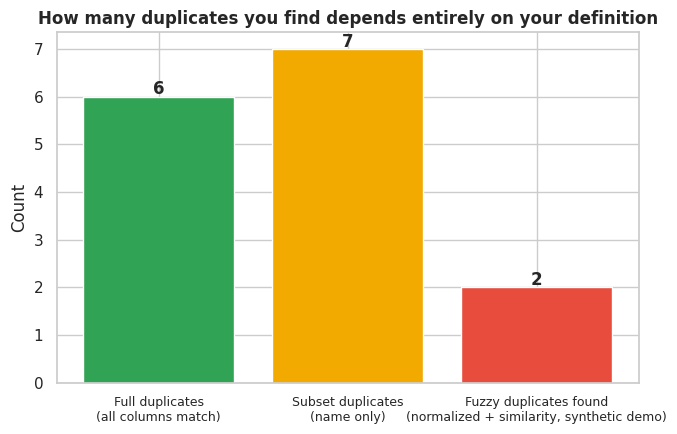

In [10]:
counts = {
    'Full duplicates\n(all columns match)': df.duplicated().sum(),
    'Subset duplicates\n(name only)': df.duplicated(subset=['name']).sum(),
    'Fuzzy duplicates found\n(normalized + similarity, synthetic demo)': len(fuzzy_pairs),
}
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(counts.keys(), counts.values(), color=['#31a354', '#f2a900', '#e74c3c'])
ax.set_ylabel('Count')
ax.set_title('How many duplicates you find depends entirely on your definition', fontweight='bold', fontsize=12)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, str(h), ha='center', fontweight='bold')
plt.xticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## Key takeaways

| Technique | Catches | Risk |
|---|---|---|
| **Full-row `duplicated()`/`drop_duplicates()`** | Exact copies across every column | Misses anything with even one differing field (e.g. a re-typed timestamp) |
| **Subset-based dedup** | Same "entity" identified by a chosen set of columns | False positives if the subset isn't truly a unique identifier |
| **Normalization (case/whitespace) + dedup** | Formatting inconsistencies | Won't catch actual typos |
| **Fuzzy string matching** | Typos and near-miss spellings | Needs a carefully tuned similarity threshold — too low creates false positives, too high misses real dupes |

Always inspect *what* got flagged before you drop anything — as we saw with the two different "krishna" rows, a duplicate-looking record isn't always actually a duplicate.

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Any duplicates at all? | `df.duplicated().any()` |
| How many | `df.duplicated().sum()` |
| Show every copy | `df[df.duplicated(keep=False)]` |
| Remove, keep the first | `df.drop_duplicates()` |
| Remove, keep the last | `df.drop_duplicates(keep='last')` |
| Remove every copy | `df.drop_duplicates(keep=False)` |
| On chosen columns only | `df.drop_duplicates(subset=['name','city'])` |
| Duplicates in one column | `df['email'].duplicated().sum()` |
| Count of each value | `df['name'].value_counts()` |
| Normalise before comparing | `df['c'].str.strip().str.lower()` |
| Renumber after dropping | `… .reset_index(drop=True)` |

### Adapting this in the exam

- 'Remove duplicate records' → decide first *which columns define a duplicate*, then `drop_duplicates(subset=[...])`.
- 'Which rows are duplicated?' → `df[df.duplicated(keep=False)]` shows every copy so you can see them together.
- Always report the row count before and after — that number is the evidence your treatment worked.

### Traps that cost marks

- An ID column makes every row unique. Always pass `subset=` with the columns that actually identify a record.
- `drop_duplicates()` keeps the **first** occurrence by default. If later records are the corrected ones, you want `keep='last'`.
- `keep=False` deletes *all* copies including the original — rarely what you want, but useful for inspection.
- Exact matching misses `'Raju'` vs `'raju '`. Strip and lowercase text keys before comparing.
- After dropping rows the index has gaps — add `.reset_index(drop=True)`.
- Two rows sharing a name are not necessarily the same person. Inspect what got flagged before deleting anything.